## **Imports**

In [1]:
import os
import glob
import json
import math
import joblib

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## **Loading Dataset**

In [3]:
data_path = "/kaggle/input/datasets/ang3loliveira/malware-analysis-datasets-api-call-sequences/dynamic_api_call_sequence_per_malware_100_0_306.csv"
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (43876, 102)

First 5 rows:


,hash,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
0,071e8c3f8922e186e57548cd4c703a5d,112,274,158,215,274,158,215,298,76,...,71,297,135,171,215,35,208,56,71,1
1,33f8e6d08a6aae939f25a8e0d63dd523,82,208,187,208,172,117,172,117,172,...,81,240,117,71,297,135,171,215,35,1
2,b68abd064e975e1c6d5f25e748663076,16,110,240,117,240,117,240,117,240,...,65,112,123,65,112,123,65,113,112,1
3,72049be7bd30ea61297ea624ae198067,82,208,187,208,172,117,172,117,172,...,208,302,208,302,187,208,302,228,302,1
4,c9b3700a77facf29172f32df6bc77f48,82,240,117,240,117,240,117,240,117,...,209,260,40,209,260,141,260,141,260,1


## **Preprocessing**

In [4]:
# 1. Locate sequence columns (t_0, t_1, ... t_99) and target label
seq_cols = [c for c in df.columns if c.startswith('t_')]
if not seq_cols:
    ignore_cols = ['hash', 'malware', 'class', 'label', 'Category']
    seq_cols = [c for c in df.columns if c not in ignore_cols]

target_col = 'malware' if 'malware' in df.columns else 'class'

# 2. Extract features (X) and target (y)
X_seq = df[seq_cols].values.astype(np.int64)
y_labels = df[target_col].values.astype(np.int64)

# 3. Calculate sequence parameters
num_samples, seq_len = X_seq.shape
vocab_size = int(X_seq.max()) + 1  # Unique API call IDs + 1

print(f"Number of samples: {num_samples}")
print(f"Sequence length per sample: {seq_len}")
print(f"Vocabulary size (Unique API Calls): {vocab_size}")
print(f"Target distribution:\n{pd.Series(y_labels).value_counts()}")




Number of samples: 43876
Sequence length per sample: 100
Vocabulary size (Unique API Calls): 307
Target distribution:
1    42797
0     1079
Name: count, dtype: int64


In [5]:
# 4. Train / Validation / Test Split (70% Train, 15% Val, 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_seq, y_labels, test_size=0.30, random_state=42, stratify=y_labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(30713, 100) (6581, 100) (6582, 100)
(30713,) (6581,) (6582,)


In [6]:
# 5. Save Preprocessing Config
pipeline_config = {
    "seq_cols": seq_cols,
    "seq_len": seq_len,
    "vocab_size": vocab_size,
    "num_classes": len(np.unique(y_labels)),
    "target_mapping": {0: "Goodware/Benign", 1: "Malware"}
}

pipeline_path = "/kaggle/working/transformer_preprocessing_pipeline.json"
with open(pipeline_path, "w") as f:
    json.dump(pipeline_config, f, indent=4)


print(f"\nPreprocessing configuration saved to: {pipeline_path}")


Preprocessing configuration saved to: /kaggle/working/transformer_preprocessing_pipeline.json


## **Data Loaders**

In [7]:
class APICallDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

In [8]:
BATCH_SIZE = 64

train_dataset = APICallDataset(X_train, y_train)
val_dataset   = APICallDataset(X_val, y_val)
test_dataset  = APICallDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 480 | Val batches: 103 | Test batches: 103


## **Model**

In [29]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # Shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x

class APITransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, dim_feedforward=256, num_classes=2, dropout=0.12):
        super(APITransformerClassifier, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        out = self.embedding(x)
        out = self.pos_encoder(out)
        out = self.transformer_encoder(out)
        out = out.mean(dim=1)  # Global Average Pooling over temporal dimension
        out = self.classifier(out)
        return out

In [30]:
num_classes = pipeline_config["num_classes"]
model = APITransformerClassifier(vocab_size=vocab_size, num_classes=num_classes).to(device)
print(model)

APITransformerClassifier(
  (embedding): Embedding(307, 128)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.12, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.12, inplace=False)
        (dropout2): Dropout(p=0.12, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.12, inplace=False)
    (3): Linear(in_features=64, out_

## **Training**

In [31]:
# Calculate exact inverse frequency weights automatically
class_counts = np.bincount(y_train)
total_samples = len(y_train)
weights = total_samples / (2.0 * class_counts)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

print(f"Calculated Class Weights: {class_weights}")

Calculated Class Weights: tensor([20.3397,  0.5126], device='cuda:0')


In [32]:
# Pass class_weights directly into CrossEntropyLoss
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 8

In [33]:
print("Training Custom Transformer Model...\n")
model.train()

for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    
    for seqs, labels in train_loader:
        seqs, labels = seqs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(seqs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * seqs.size(0)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc*100:.2f}%")

Training Custom Transformer Model...

Epoch [1/8] - Loss: 0.4403 - Accuracy: 86.79%
Epoch [2/8] - Loss: 0.2734 - Accuracy: 91.74%
Epoch [3/8] - Loss: 0.2380 - Accuracy: 93.09%
Epoch [4/8] - Loss: 0.2093 - Accuracy: 93.24%
Epoch [5/8] - Loss: 0.2018 - Accuracy: 93.73%
Epoch [6/8] - Loss: 0.1769 - Accuracy: 94.26%
Epoch [7/8] - Loss: 0.1651 - Accuracy: 94.30%
Epoch [8/8] - Loss: 0.1551 - Accuracy: 95.18%


In [34]:
# Save Model File
model_pth_path = "/kaggle/working/api_transformer_model.pth"
torch.save(model.state_dict(), model_pth_path)
print(f"\nTrained Transformer model weights saved to: {model_pth_path}")


Trained Transformer model weights saved to: /kaggle/working/api_transformer_model.pth


## **Evaluation**

In [35]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for seqs, labels in test_loader:
        seqs = seqs.to(device)
        outputs = model(seqs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

target_names = ["Goodware/Benign", "Malware"]
acc = accuracy_score(all_labels, all_preds)
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
class_report_str = classification_report(all_labels, all_preds, target_names=target_names)

print("=== Base Transformer Evaluation Results ===")
print(f"Test Accuracy: {acc * 100:.2f}%")
print(f"Weighted F1-Score: {f1_weighted:.4f}\n")
print("Classification Report:\n", class_report_str)

=== Base Transformer Evaluation Results ===
Test Accuracy: 94.55%
Weighted F1-Score: 0.9586

Classification Report:
                  precision    recall  f1-score   support

Goodware/Benign       0.30      0.92      0.45       162
        Malware       1.00      0.95      0.97      6420

       accuracy                           0.95      6582
      macro avg       0.65      0.93      0.71      6582
   weighted avg       0.98      0.95      0.96      6582



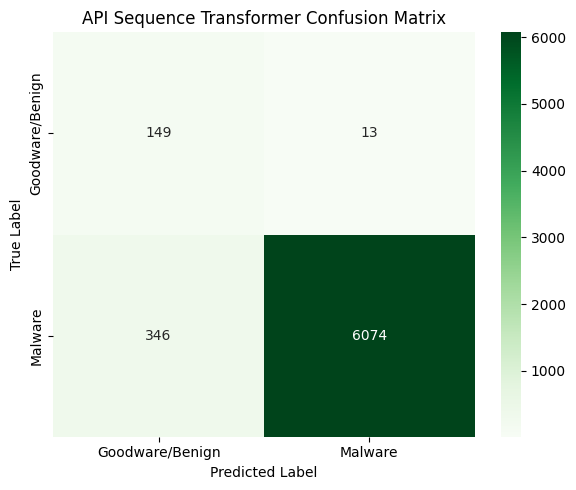

In [36]:
# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title('API Sequence Transformer Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## **Caliberation**

In [37]:
print("=== Performing Probability Calibration (Platt Scaling via Logistic Regression) ===")

def extract_logits_and_labels(data_loader, model_net):
    """Utility to extract raw logit outputs from the PyTorch model."""
    model_net.eval()
    logits_list = []
    labels_list = []
    with torch.no_grad():
        for seqs, labels in data_loader:
            seqs = seqs.to(device)
            outputs = model_net(seqs)
            logits_list.append(outputs.cpu().numpy())
            labels_list.append(labels.numpy())
    return np.vstack(logits_list), np.concatenate(labels_list)

# 1. Extract raw uncalibrated logits on Validation and Test sets
val_logits, val_y = extract_logits_and_labels(val_loader, model)
test_logits, test_y = extract_logits_and_labels(test_loader, model)

# 2. Fit Platt Scaler (Logistic Regression) on Validation Logits
platt_scaler = LogisticRegression(C=1.0, solver='lbfgs')
platt_scaler.fit(val_logits, val_y)

# 3. Print Platt Weights & Biases
print("\n=== Platt Scaling Parameters ===")
print(f"Weights (A): {platt_scaler.coef_}")
print(f"Bias (B):    {platt_scaler.intercept_}")

=== Performing Probability Calibration (Platt Scaling via Logistic Regression) ===

=== Platt Scaling Parameters ===
Weights (A): [[-1.00314332  0.53913218]]
Bias (B):    [3.45562363]


In [38]:
# 4. Predict Calibrated Probabilities on Test set
calibrated_test_probs = platt_scaler.predict_proba(test_logits)
calibrated_preds = np.argmax(calibrated_test_probs, axis=1)

# 5. Compute Calibrated Performance Metrics for Product of Experts
calibrated_acc = accuracy_score(test_y, calibrated_preds)
calibrated_f1_weighted = f1_score(test_y, calibrated_preds, average='weighted')
calibrated_f1_per_class = f1_score(test_y, calibrated_preds, average=None)

print(f"\nCalibrated Test Accuracy:     {calibrated_acc * 100:.2f}%")
print(f"Calibrated Weighted F1 Score: {calibrated_f1_weighted:.4f}")
print(f"Calibrated Per-Class F1s:     {dict(zip(target_names, calibrated_f1_per_class))}")


Calibrated Test Accuracy:     98.69%
Calibrated Weighted F1 Score: 0.9862
Calibrated Per-Class F1s:     {'Goodware/Benign': np.float64(0.7034482758620689), 'Malware': np.float64(0.9933198695044275)}


In [39]:
# 6. Save Platt Scaler & Calibrated Performance Metrics
platt_scaler_path = "/kaggle/working/transformer_platt_scaler.joblib"
joblib.dump(platt_scaler, platt_scaler_path)

calibrated_metrics = {
    "accuracy": calibrated_acc,
    "f1_score_weighted": calibrated_f1_weighted,
    "f1_score_per_class": dict(zip(target_names, calibrated_f1_per_class.tolist()))
}

with open("/kaggle/working/transformer_calibrated_metrics.json", "w") as f:
    json.dump(calibrated_metrics, f, indent=4)

print(f"\nSaved Platt Scaler to: {platt_scaler_path}")


Saved Platt Scaler to: /kaggle/working/transformer_platt_scaler.joblib


## **Inference**

In [40]:
def transformer_calibrated_inference(input_sequences, model_path, platt_scaler_path, config_path):
    """
    Performs standalone inference on new API sequence samples using the Transformer + Platt Scaled calibrator.
    """
    # 1. Load Preprocessing Config
    with open(config_path, 'r') as f:
        config = json.load(f)
        
    vocab_size = config["vocab_size"]
    num_classes = config["num_classes"]
    
    # 2. Format input sequence
    if isinstance(input_sequences, pd.DataFrame):
        sequences = input_sequences.values.astype(np.int64)
    elif isinstance(input_sequences, np.ndarray):
        sequences = input_sequences.astype(np.int64)
    else:
        sequences = np.array(input_sequences, dtype=np.int64)
        
    if sequences.ndim == 1:
        sequences = np.expand_dims(sequences, axis=0)

    # 3. Reconstruct PyTorch Model Architecture & Load State Dict
    inference_model = APITransformerClassifier(vocab_size=vocab_size, num_classes=num_classes).to(device)
    inference_model.load_state_dict(torch.load(model_path, map_location=device))
    inference_model.eval()

    # 4. Forward Pass to Get Raw Logits
    seq_tensor = torch.tensor(sequences, dtype=torch.long).to(device)
    with torch.no_grad():
        raw_logits = inference_model(seq_tensor).cpu().numpy()

    # 5. Apply Platt Scaler
    platt_scaler = joblib.load(platt_scaler_path)
    calibrated_probs = platt_scaler.predict_proba(raw_logits)
    pred_class_ids = np.argmax(calibrated_probs, axis=1)

    # 6. Map predictions
    target_mapping = {0: "Goodware/Benign", 1: "Malware"}
    class_names = [target_mapping.get(cid, f"Class_{cid}") for cid in pred_class_ids]

    results = pd.DataFrame({
        "Predicted_Class_ID": pred_class_ids,
        "Predicted_Class": class_names,
        "Calibrated_Confidence": np.max(calibrated_probs, axis=1),
        "Prob_Benign": calibrated_probs[:, 0],
        "Prob_Malware": calibrated_probs[:, 1]
    })

    return results

In [42]:
print(len(X_test))

6582


In [45]:
# --- SAMPLE INFERENCE RUN ---
# Select 3 test samples (including both Goodware and Malware)
sample_indices = [0, 1, 5, 8]
inference_samples = X_test[sample_indices]
ground_truth_numeric = y_test[sample_indices]

target_mapping = {0: "Goodware/Benign", 1: "Malware"}
ground_truth_labels = [target_mapping[gt] for gt in ground_truth_numeric]

print("=== Running Custom Transformer Inference Pipeline ===")
inference_results = transformer_calibrated_inference(
    input_sequences=inference_samples,
    model_path="/kaggle/working/api_transformer_model.pth",
    platt_scaler_path="/kaggle/working/transformer_platt_scaler.joblib",
    config_path="/kaggle/working/transformer_preprocessing_pipeline.json"
)

# Insert Ground Truth for comparison
inference_results.insert(0, "Ground_Truth", ground_truth_labels)

print("\nInference Results for 3 Test Samples:")
display(inference_results)

=== Running Custom Transformer Inference Pipeline ===

Inference Results for 3 Test Samples:


,Ground_Truth,Predicted_Class_ID,Predicted_Class,Calibrated_Confidence,Prob_Benign,Prob_Malware
0,Malware,1,Malware,0.999970,0.000030,0.999970
1,Malware,1,Malware,0.998985,0.001015,0.998985
2,Goodware/Benign,0,Goodware/Benign,0.934941,0.934941,0.065059
3,Goodware/Benign,0,Goodware/Benign,0.938828,0.938828,0.061172
